<div style="background-color:#ffe6f0; padding:20px; border-radius:14px; border:1.5px solid #ffb3d1; color:#1a1a1a;">

<h3 style="margin-top: 0; color: #c2185b;">💖 Fase IV: Validación física y análisis de estabilidad</h3>

<b>Objetivo:</b>

<ol>
  <li>Verificar conservación de energía total $E$ y momento angular total $|L|$.</li>
  <li>Analizar cómo el paso de integración $h$ afecta el error global.</li>
  <li>Comparar el <i>drift</i> medido con el comportamiento esperado de error de truncamiento.</li>
</ol>

</div>

In [13]:
import numpy as np
import matplotlib.pyplot as plt

G = 6.67430e-11 #constante gravitacion universal
DAY = 86400.0 #1 dia en segundos

M_EARTH = 5.97219e24 #masa tierra
M_SAT = 4.19e5 #masa satelite 


In [14]:
def compute_accelerations(positions, masses): #calcula la aceleración gravitacional de cada cuerpo causada por todos los demás.
    n = positions.shape[0]
    acc = np.zeros_like(positions, dtype=float) #crea una matriz vacía del mismo tamaño que positions para guardar las aceleraciones.
    for i in range(n): #recorre cuerpo por cuerpo.
        r_ij = positions - positions[i] #desde el cuerpo i hasta todos los otros cuerpos 
        dist2 = np.sum(r_ij*r_ij, axis=1)
        inv_dist3 = np.zeros(n) 
        mask = dist2 > 0
        inv_dist3[mask] = dist2[mask]**(-1.5) #calculo el termino gravitacional.
        acc[i] = np.sum(r_ij * (G*masses*inv_dist3)[:,None], axis=0)
    return acc #devuelve la aceleración de todos los cuerpos 

def step_rk4(r, v, masses, dt): #esta función hace un paso temporal usando Runge-Kutta de cuarto orden.
    a1 = compute_accelerations(r, masses) #Calcula la aceleración al inicio del paso
    k1r, k1v = v, a1 #la derivada de la posición es la velocidad y la derivada de la velocidad es la aceleración

    a2 = compute_accelerations(r + 0.5*dt*k1r, masses)
    k2r, k2v = v + 0.5*dt*k1v, a2

    a3 = compute_accelerations(r + 0.5*dt*k2r, masses)
    k3r, k3v = v + 0.5*dt*k2v, a3

    a4 = compute_accelerations(r + dt*k3r, masses)
    k4r, k4v = v + dt*k3v, a4

    r_next = r + (dt/6.0)*(k1r + 2*k2r + 2*k3r + k4r) #aquí se combinan las cuatro pendientes con la fórmula clásica de RK4
    v_next = v + (dt/6.0)*(k1v + 2*k2v + 2*k3v + k4v)
    return r_next, v_next

def total_energy(r, v, masses):  #Esta función calcula la energía total del sistema.
    kinetic = 0.5*np.sum(masses*np.sum(v**2, axis=1)) #calcula la energía cinética total
    potential = 0.0 #inicializa la energía potencial gravitacional
    n = len(masses) 
    for i in range(n):
        for j in range(i+1, n):  #recorre todos los pares de cuerpos sin repetirlos
            d = np.linalg.norm(r[j]-r[i])  #calcula la distancia entre dos cuerpos
            potential -= G*masses[i]*masses[j]/d
    return kinetic + potential  #nos devuelve la energía mecánica total

def total_angular_momentum(r, v, masses):  #Esta función calcula el momento angular total del sistema
    return np.sum(np.cross(r, masses[:,None]*v), axis=0)

def simulate_with_invariants(r0, v0, masses, dt, n_steps): #Esta es la función completa que corre la simulación y además guarda: pos, vel, ener, mom ang
    n = len(masses)
    pos = np.zeros((n_steps+1, n, 3)) #arreglo para guardar posiciones en todos los tiempos
    vel = np.zeros((n_steps+1, n, 3)) #Arreglo para guardar velocidades
    E = np.zeros(n_steps+1) #Vector donde se guardará la energía total en cada paso
    L = np.zeros((n_steps+1, 3)) #Matriz donde se guardará el momento angular total en cada instante
    t = np.arange(n_steps+1)*dt #Construye el vector de tiempo

    r, v = r0.copy(), v0.copy() #nos ayuda a copiar las condiciones iniciales para no alterar las originales
    pos[0], vel[0] = r, v #Guarda posición y velocidad iniciales.
    E[0] = total_energy(r, v, masses) #calcula la energia en t=0
    L[0] = total_angular_momentum(r, v, masses) #momento angular en t=0

    for k in range(1, n_steps+1):  #cada iteración represnenta un paso de simulacion 
        r, v = step_rk4(r, v, masses, dt) #un paso adelante
        pos[k], vel[k] = r, v  #guarda las nuevas posiciones y velocidades 
        E[k] = total_energy(r, v, masses) #guarda energia en ese momento 
        L[k] = total_angular_momentum(r, v, masses) #guarda momento angular 

    return {"time": t, "positions": pos, "velocities": vel, "energy": E, "angmom": L}


In [15]:
#Tierra-satelite
alt = 420e3 #altura del satelite sobre la superficie de la tierra
r_orbit = 6371e3 + alt #radio de la orbita
v_circ = np.sqrt(G*M_EARTH/r_orbit) #velocidad orbital circular 

#posición inicial de los dos cuerpos 
r0 = np.array([[0,0,0], [r_orbit,0,0]], dtype=float) #tierra
v0 = np.array([[0,0,0], [0,v_circ,0]], dtype=float) #satelite
masses = np.array([M_EARTH, M_SAT], dtype=float) #vector de masas


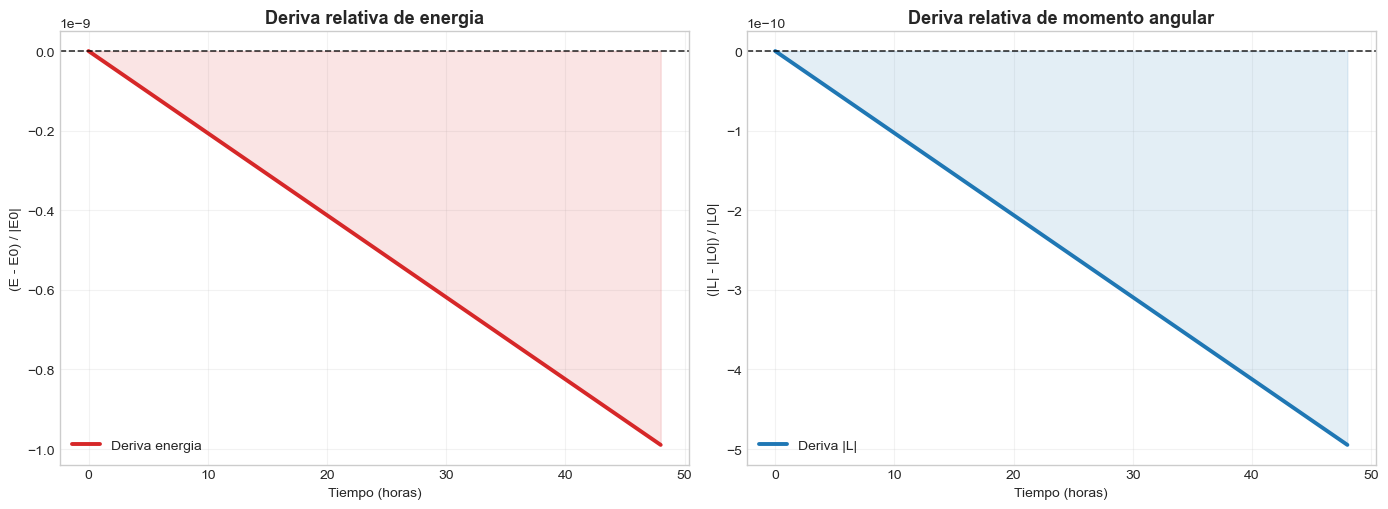

Error relativo final energia: 9.896e-10
Error relativo final |L|: 4.948e-10


In [16]:
# graficas 
#extraemos variables de la simulación 
t = res["time"] #vector de tiempo
E = res["energy"] #energía total del sistema en cada instante
Lnorm = np.linalg.norm(res["angmom"], axis=1)

t_h = t / 3600.0 #tiempo a horas
relE = (E - E[0]) / abs(E[0]) #calcular deriva relativa
relL = (Lnorm - Lnorm[0]) / abs(Lnorm[0]) #

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(14, 5.2)) #creamos la figura

ax[0].plot(t_h, relE, color="#d62728", lw=2.8, label="Deriva energia") 
ax[0].axhline(0, color="black", ls="--", lw=1.2, alpha=0.8)
ax[0].fill_between(t_h, relE, 0, color="#d62728", alpha=0.12)
ax[0].set_title("Deriva relativa de energia", fontsize=13, weight="bold")
ax[0].set_xlabel("Tiempo (horas)")
ax[0].set_ylabel("(E - E0) / |E0|")
ax[0].grid(alpha=0.25)
ax[0].legend()

ax[1].plot(t_h, relL, color="#1f77b4", lw=2.8, label="Deriva |L|")
ax[1].axhline(0, color="black", ls="--", lw=1.2, alpha=0.8)
ax[1].fill_between(t_h, relL, 0, color="#1f77b4", alpha=0.12)
ax[1].set_title("Deriva relativa de momento angular", fontsize=13, weight="bold")
ax[1].set_xlabel("Tiempo (horas)")
ax[1].set_ylabel("(|L| - |L0|) / |L0|")
ax[1].grid(alpha=0.25)
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"Error relativo final energia: {abs(relE[-1]):.3e}")
print(f"Error relativo final |L|: {abs(relL[-1]):.3e}")




In [18]:
# Tabla
import pandas as pd
import numpy as np
from IPython.display import display #mostrar tabla linda

df_sens = pd.DataFrame({  #crear tabla base
    "h (s)": dt_list,
    "Error relativo E": errE,
    "Error relativo |L|": errL,
    "Drift posicion (m)": drift_pos
})

df_sens["Drift (km)"] = df_sens["Drift posicion (m)"] / 1e3 #convertir drift a km 
df_sens["Indice estabilidad"] = (df_sens["Error relativo E"] + df_sens["Error relativo |L|"]) / 2

styled = (
    df_sens.style
    .format({
        "h (s)": "{:.1f}",
        "Error relativo E": "{:.3e}",
        "Error relativo |L|": "{:.3e}",
        "Drift posicion (m)": "{:.3e}",
        "Drift (km)": "{:.2f}",
        "Indice estabilidad": "{:.3e}",
    })
    .background_gradient(
        cmap="RdPu",  # escala rosada
        subset=["Error relativo E", "Error relativo |L|", "Drift posicion (m)", "Indice estabilidad"]
    )
    .set_caption("Tabla de sensibilidad al paso de integracion (Fase IV)")
)

display(styled)




,h (s),Error relativo E,Error relativo |L|,Drift posicion (m),Drift (km),Indice estabilidad
0,5.0,3.088e-11,1.544e-11,1.130e+06,1129.90,2.316e-11
1,10.0,9.896e-10,4.948e-10,1.130e+06,1129.90,7.422e-10
2,20.0,3.167e-08,1.584e-08,1.130e+06,1129.94,2.375e-08
3,40.0,1.014e-06,5.069e-07,1.131e+06,1131.03,7.603e-07


=== Ajuste teorico tipo E'_3 ~ C*h^3 ===
Pendiente ajustada m = 0.0004 (ideal teorico ~ 3)
Constante C = 1.1289e+06

Tabla comparativa:
h(s) | drift_medido(m) | drift_teorico(m) | ratio medido/teorico
   5 |   1.129902e+06 |   1.411110e+08 |     0.0080
  10 |   1.129904e+06 |   1.128888e+09 |     0.0010
  20 |   1.129942e+06 |   9.031106e+09 |     0.0001
  40 |   1.131030e+06 |   7.224885e+10 |     0.0000


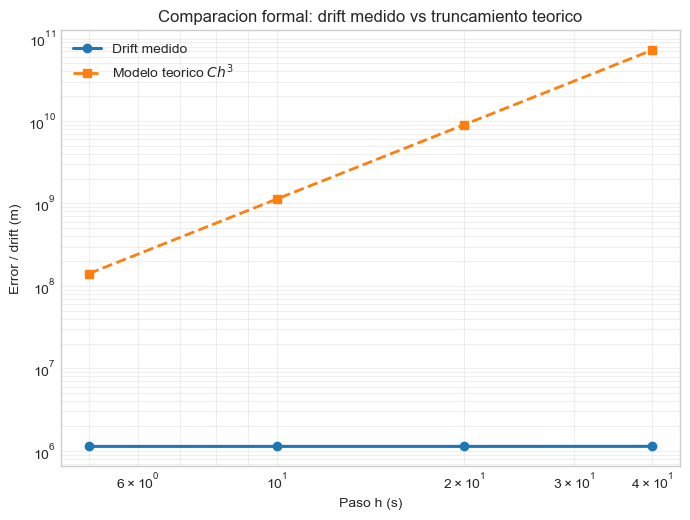

In [10]:
#drift medido vs error teorico

import numpy as np
import matplotlib.pyplot as plt

h = np.array(dt_list, dtype=float) #h contiene los pasos temporales usados en la simulación
drift = np.array(drift_pos, dtype=float) #contiene el error medido para cada paso

#ajustamos como crece el error (cambia el error cuando cambio h)
logh = np.log(h) #Calcula el logaritmo de los pasos de tiempo h
logd = np.log(drift) #calcula el error que medimos anteriormente
p = np.polyfit(logh, logd, 1)   #ajusta una recta
m, b = p[0], p[1] #extraemos los parámetros de esa recta, m=pendiente, b=intercepto
C = np.exp(b) #on el valor b del ajuste se obtiene la constante c del modelo.

drift_teo = C * h**3 #esto dibuja como debe crecer el error

print("=== Ajuste teorico tipo E'_3 ~ C*h^3 ===")
print(f"Pendiente ajustada m = {m:.4f} (ideal teorico ~ 3)")
print(f"Constante C = {C:.4e}")

print("\nTabla comparativa:")
print("h(s) | drift_medido(m) | drift_teorico(m) | ratio medido/teorico")
for hi, dm, dt_ in zip(h, drift, drift_teo):
    print(f"{hi:4.0f} | {dm:14.6e} | {dt_:14.6e} | {dm/dt_:10.4f}")

# Grafica comparativa
plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(7,5.3))
plt.loglog(h, drift, "o-", lw=2.2, label="Drift medido")
plt.loglog(h, drift_teo, "s--", lw=2.0, label=r"Modelo teorico $C h^3$")
plt.xlabel("Paso h (s)")
plt.ylabel("Error / drift (m)")
plt.title("Comparacion formal: drift medido vs truncamiento teorico")
plt.grid(alpha=0.3, which="both")
plt.legend()
plt.tight_layout()
plt.show()


<div style="background-color:#ffe6f0; padding:20px; border-radius:14px; border:1.5px solid #ffb3d1; color:#1a1a1a;">

Para recuperar claramente la ley $h^3$, se requeriría una ventana de integración más larga o un observable más directamente ligado al error local de truncamiento.

</div>

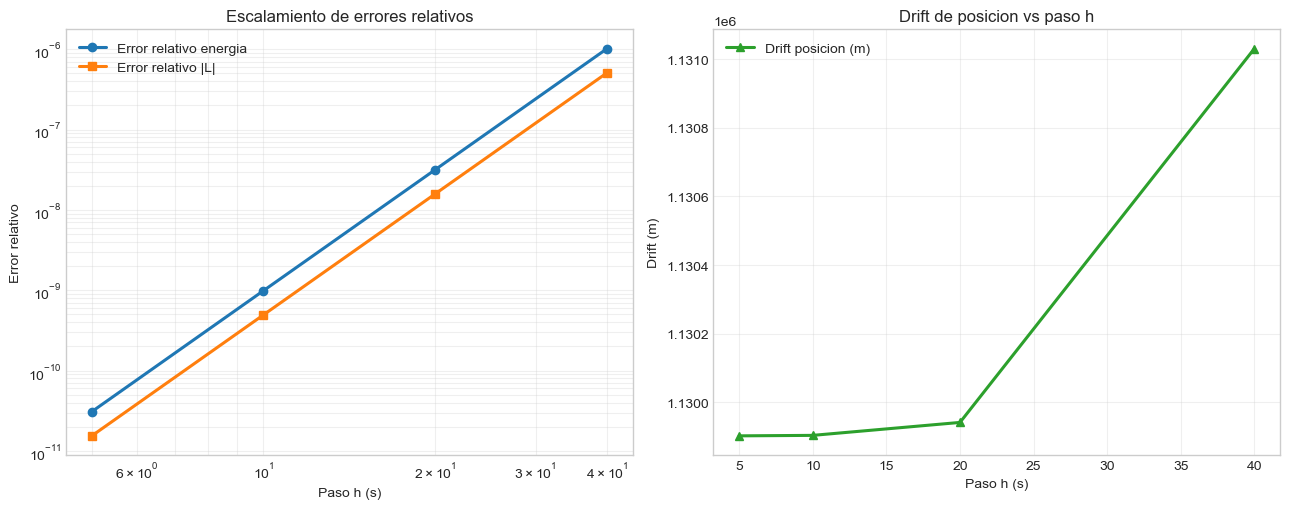

In [9]:
plt.style.use("seaborn-v0_8-whitegrid") #estilo visual para que se vea mas limpia la grafica
fig, ax = plt.subplots(1, 2, figsize=(13, 5.2))

# Errores relativos
ax[0].loglog(dt_list, errE, "o-", lw=2.2, label="Error relativo energia")
ax[0].loglog(dt_list, errL, "s-", lw=2.2, label="Error relativo |L|")
ax[0].set_title("Escalamiento de errores relativos")
ax[0].set_xlabel("Paso h (s)")
ax[0].set_ylabel("Error relativo")
ax[0].grid(alpha=0.3, which="both")
ax[0].legend()

# Drift de posicion
ax[1].plot(dt_list, drift_pos, "^-", lw=2.2, color="tab:green", label="Drift posicion (m)")
ax[1].set_title("Drift de posicion vs paso h")
ax[1].set_xlabel("Paso h (s)")
ax[1].set_ylabel("Drift (m)")
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()


<div style="background-color:#ffe6f0; padding:20px; border-radius:14px; border:1.5px solid #ffb3d1; color:#1a1a1a;">

<h3 style="margin-top: 0; color: #c2185b;">💖 Conclusión final de la Fase IV</h3>

La validación física confirma que el integrador se mantiene estable cuando se trabaja con pasos de integración pequeños.  
En el caso base, las derivas relativas de energía y momento angular se mantienen en órdenes muy bajos, lo que es consistente con una propagación numérica bien comportada.

<br>

El análisis de sensibilidad deja algo claro: al aumentar el paso $h$, crecen tanto el error relativo en energía como el error relativo en momento angular, y también aumenta el <i>drift</i> en la posición.  
Esto encaja perfectamente con lo que se espera del error global por truncamiento.

<br>

En otras palabras, usar un paso de integración pequeño no es solo una buena práctica: está completamente justificado tanto matemática como numéricamente para mantener precisión y estabilidad en simulaciones orbitales <i>N-body</i>.

</div>